In [1]:
import h5py
import numpy as np
import shutil
from datetime import datetime
import sys
import os
import matplotlib.pyplot as plt
import corner
import numpy as np

script_dir = os.path.abspath('/Users/cfy7qw/Documents/uva_hw/comp_astr/')
if script_dir not in sys.path:
    sys.path.append(script_dir)
%load_ext autoreload
%autoreload 2 

import kernels, modeling, plotting,  correction, file_formatting;
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import median_filter
from scipy.ndimage import generic_filter

/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:61: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Wavelength ($\mu$m)")
/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:74: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Wavelength ($\mu$m)")
/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:154: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title(f"Combined GP Analysis: {date} | $\chi^2_\\nu$: {chi2_red:.3f}")
/Users/cfy7qw/Documents/uva_hw/comp_astr/plotting.py:271: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title(f"Visit Analysis: {date} | $\chi^2_\\nu$: {chi2_red:.3f}")
/Users/cfy7qw/Documents/uva_hw/comp_astr/file_formatting.py:37: SyntaxWarning: invalid escape sequence '\m'
  w_bounds = label.replace('$\mu$m', '').strip().split('-')


In [2]:
obj_name = "PSO318"
instrument = "G235H"

all_mjds = []
all_flux_data = []
h5_files = [
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-11-06/2025-11-06_combined_SpecData.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-21/2025-10-21_combined_SpecData.h5', 
    f'/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/{obj_name}/{obj_name}_Eureka/{instrument}/2025-10-01/2025-10-01_combined_SpecData.h5'
]
for f in h5_files:
    with h5py.File(f, 'r') as h5:
        all_mjds.append(h5['time'][:])
        all_flux_data.append(h5['calibrated_optspec'][:])

global_min_mjd = np.nanmin([np.nanmin(m) for m in all_mjds])
# Define colors: [Color 1, Neutral Midpoint, Color 2]
colors = ["#c22267", "#ffffff", "#1d67e0"] 
custom_cmap = LinearSegmentedColormap.from_list("my_diverging", colors)

In [5]:
class JWSTVisit:
    def __init__(self, date, h5_path):
        self.date = date
        self.h5_path = h5_path
        
        with h5py.File(h5_path, 'r') as hf:
            self.wave_1d = hf['wave_1d'][:]
            self.time_raw = hf['time'][:]
            self.flux_2d_raw = hf['calibrated_optspec'][:]
            self.err_2d_raw = hf['calibrated_opterr'][:]
            
        # 1. White Light Curve
        w_flux_raw = np.nansum(self.flux_2d_raw, axis=1)
        w_err_raw = np.sqrt(np.nansum(self.err_2d_raw**2, axis=1))
        
        # 2. Time Mask
        self.time_mask = np.isfinite(w_flux_raw) & (w_flux_raw > 0)
        
        # 3. Apply mask to everything
        self.time = self.time_raw[self.time_mask]*24  # Convert to hours
        
        norm_val = np.nanmedian(w_flux_raw[self.time_mask])
        self.white_flux = w_flux_raw[self.time_mask] / norm_val
        self.white_error = w_err_raw[self.time_mask] / norm_val
        
        # CRITICAL: Mask the 2D arrays so they match the length of self.time
        self.flux_2d = self.flux_2d_raw[self.time_mask, :]
        self.err_2d = self.err_2d_raw[self.time_mask, :]

    def __repr__(self):
        return f"JWSTVisit({self.date}, points={len(self.time)})"

# --- Setup your visits ---
visits = [
    JWSTVisit('2025-10-01', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-01/2025-10-01_combined_SpecData.h5'),
    JWSTVisit('2025-10-21', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-21/2025-10-21_combined_SpecData.h5'),
    JWSTVisit('2025-11-06', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-11-06/2025-11-06_combined_SpecData.h5')
]

In [27]:
class JWSTVisit:
    def __init__(self, date, h5_path, global_mjd_min=global_min_mjd):
        self.date = date
        self.h5_path = h5_path
        self.global_mjd_min = global_mjd_min

        with h5py.File(h5_path, 'r') as hf:
            wave_raw = hf['wave_1d'][:]
            time_raw = hf['time'][:] # Assumed to be in MJD
            flux_2d_raw = hf['calibrated_optspec'][:]
            err_2d_raw = hf['calibrated_opterr'][:]
            
        # 1. Sort by time
        sort_idx = np.argsort(time_raw)
        time_raw = time_raw[sort_idx]
        flux_2d_raw = flux_2d_raw[sort_idx, :]
        err_2d_raw = err_2d_raw[sort_idx, :]

        # 2. White Light Curve
        w_flux_raw = np.nansum(flux_2d_raw, axis=1)
        w_err_raw = np.sqrt(np.nansum(err_2d_raw**2, axis=1))
        
        # 3. Create Time Mask
        self.time_mask = np.isfinite(w_flux_raw) & (w_flux_raw > 0)
        
        # 4. Global Unit Conversion (Hours relative to first observation)
        # Subtracting global_mjd_min ensures Visit 1 starts at 0, 
        # while later visits correctly represent the elapsed hours since then.
        raw_masked_time = time_raw[self.time_mask]
        self.time = (raw_masked_time - global_mjd_min) * 24.0
        
        # 5. Store Masked Data
        self.wave_1d = wave_raw
        norm_val = np.nanmedian(w_flux_raw[self.time_mask])
        self.white_flux = w_flux_raw[self.time_mask] / norm_val
        self.eureka_error = w_err_raw[self.time_mask] / norm_val
        self.flux_2d = flux_2d_raw[self.time_mask, :]
        self.err_2d = err_2d_raw[self.time_mask, :]

        # Build trend
        lc_trend = median_filter(self.white_flux, size=5)

        # Residuals
        residuals = self.white_flux - lc_trend

        # Empirical noise
        scatter = np.nanstd(residuals)
        self.white_error = np.full_like(self.white_flux, scatter)

visits = [
    JWSTVisit('2025-10-01', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-01/2025-10-01_combined_SpecData.h5'),
    JWSTVisit('2025-10-21', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-10-21/2025-10-21_combined_SpecData.h5'),
    JWSTVisit('2025-11-06', '/Users/cfy7qw/Documents/uva_research/Parallel_pipeline/DataAnalysis/JWST/PSO318/PSO318_Eureka/G235H/2025-11-06/2025-11-06_combined_SpecData.h5')
]


--- Processing Visit: 2025-10-01 ---


  0%|          | 0/600 [00:00<?, ?it/s]/opt/anaconda3/envs/eureka2/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 600/600 [00:01<00:00, 308.15it/s]


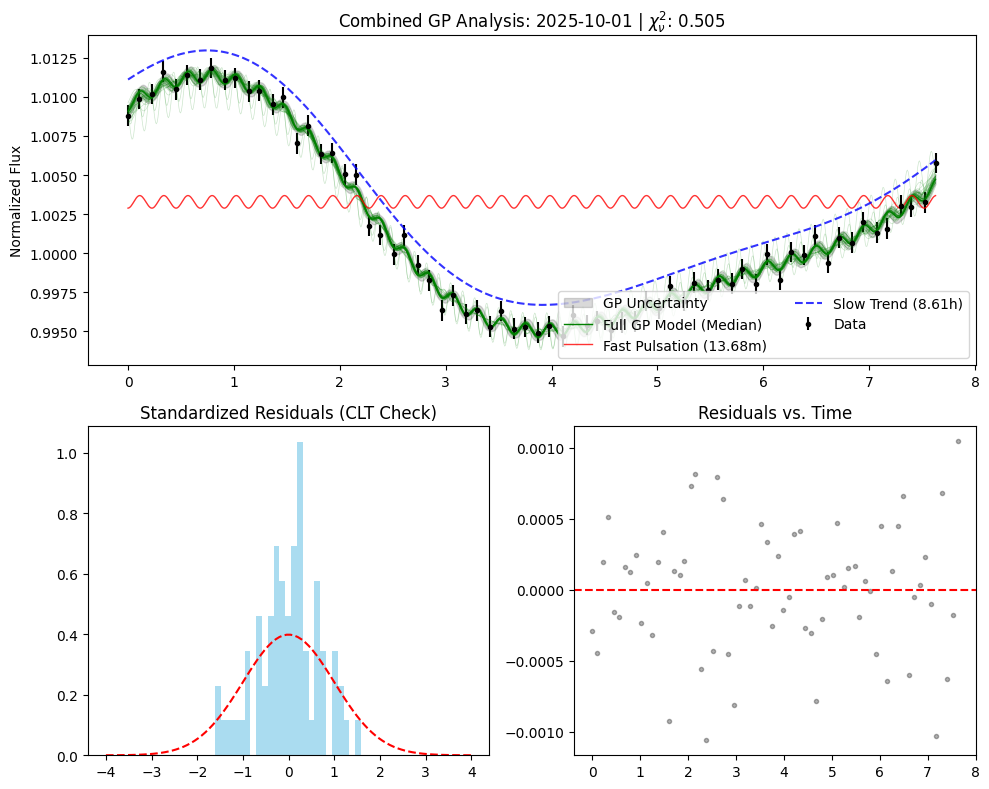


--- 2025-10-01 FINAL SUMMARY ---
Fast Period: 13.6761 min
Slow Period: 8.6076 hours
Chi-Squared Red: 0.5052 (Taller histogram = Overestimated Errors)


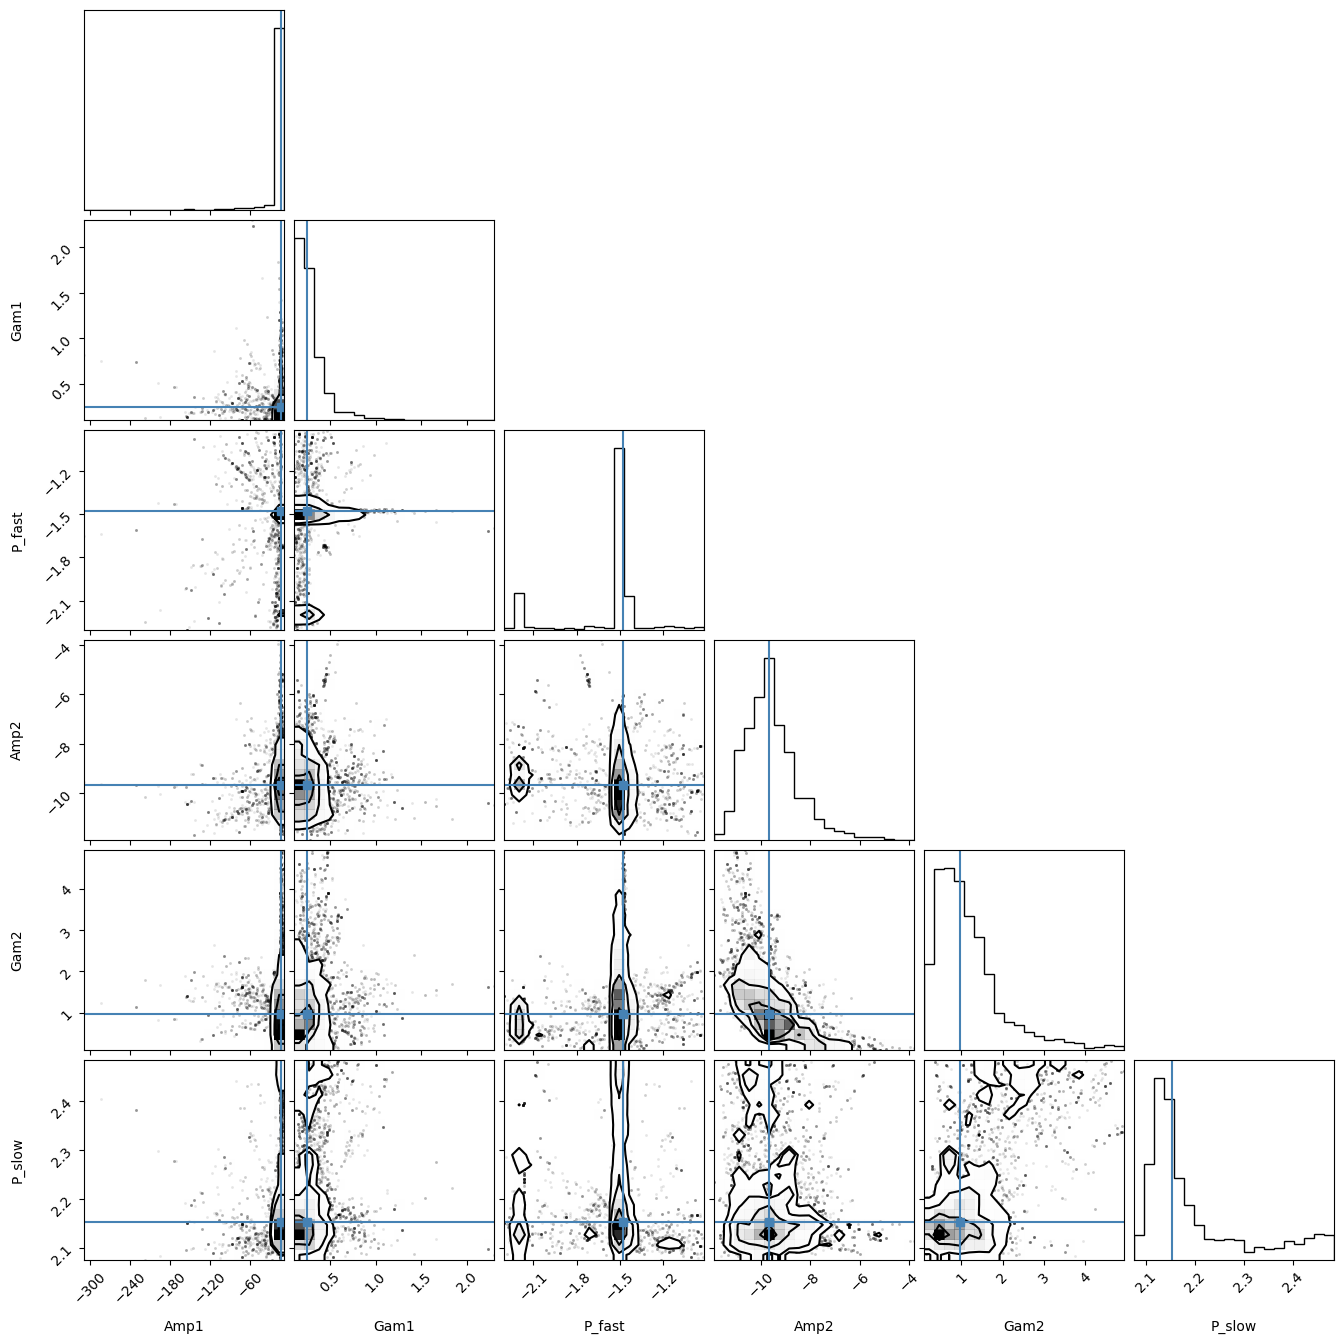


--- Processing Visit: 2025-10-21 ---


100%|██████████| 600/600 [00:01<00:00, 316.72it/s]


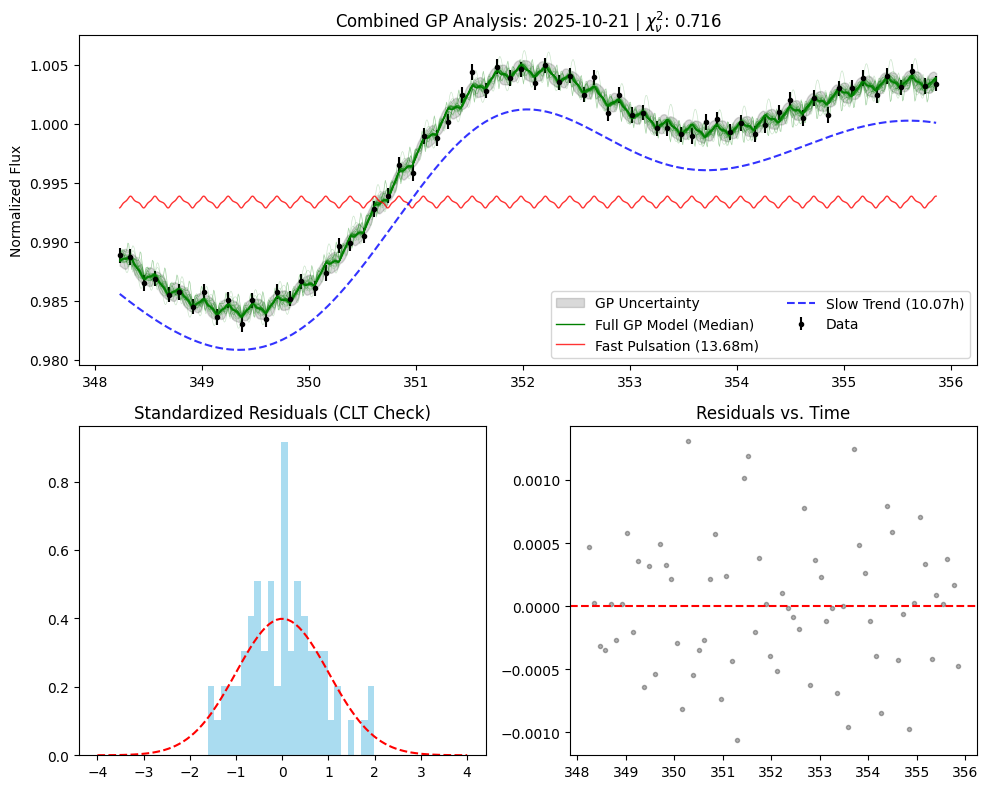


--- 2025-10-21 FINAL SUMMARY ---
Fast Period: 13.6787 min
Slow Period: 10.0651 hours
Chi-Squared Red: 0.7158 (Taller histogram = Overestimated Errors)


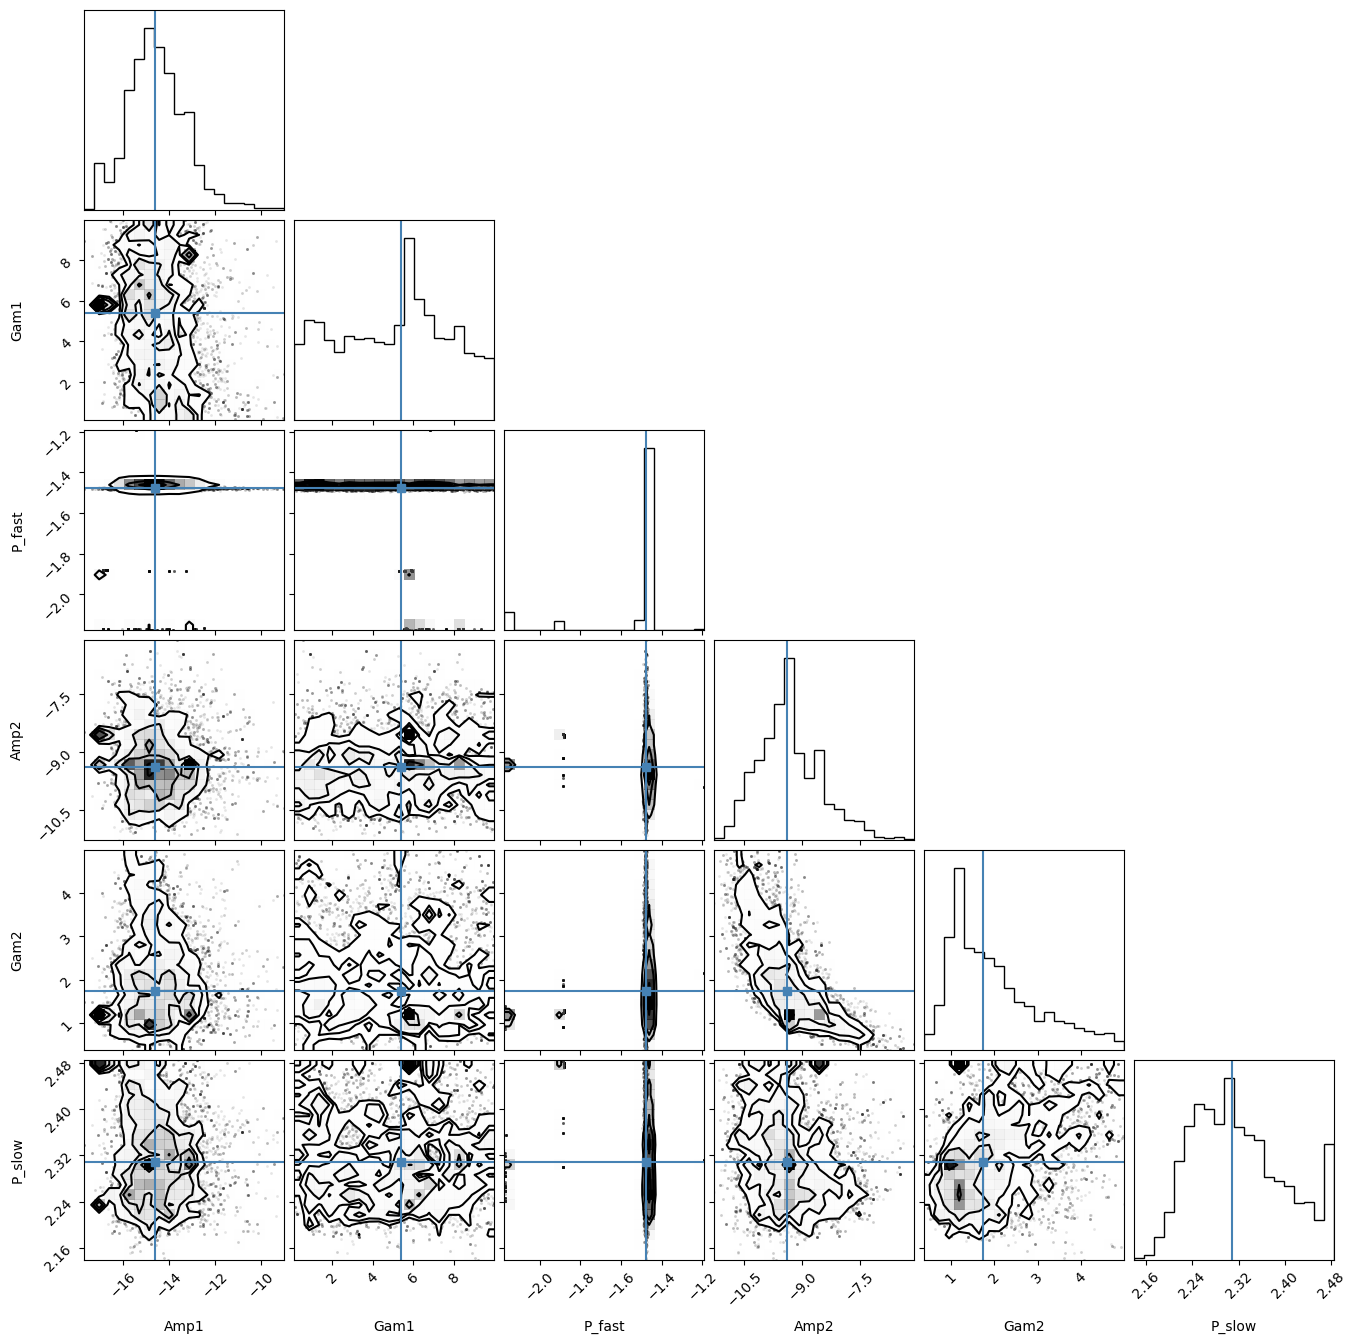


--- Processing Visit: 2025-11-06 ---


  0%|          | 0/600 [00:00<?, ?it/s]/opt/anaconda3/envs/eureka2/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 600/600 [00:01<00:00, 326.93it/s]


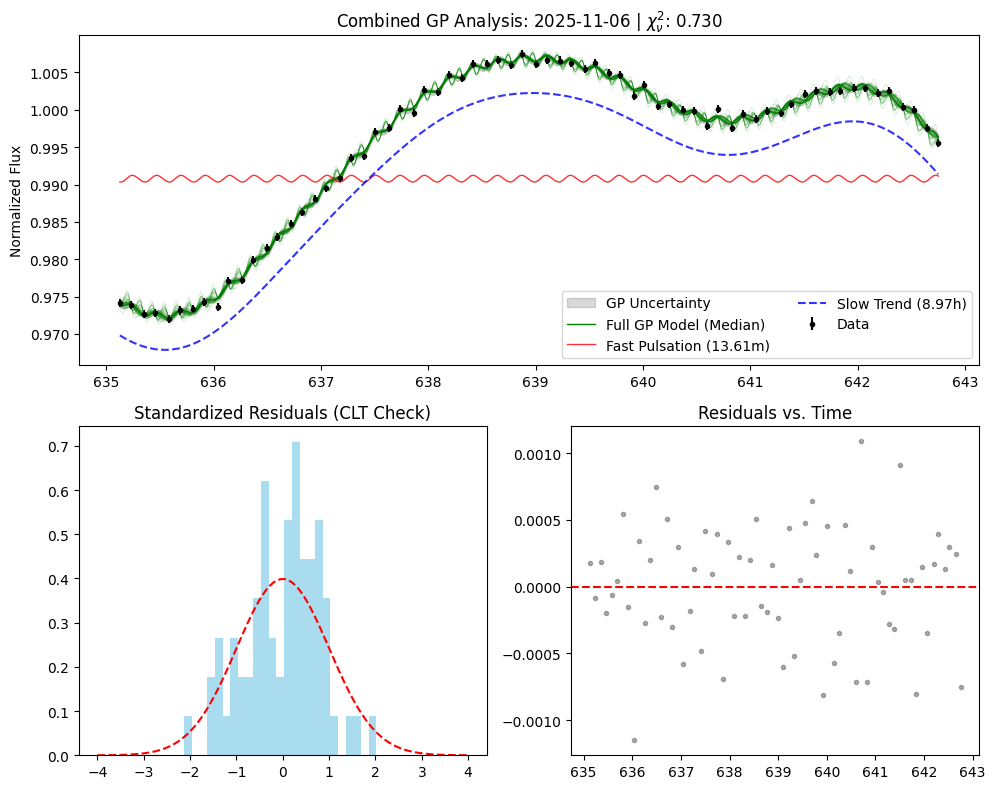


--- 2025-11-06 FINAL SUMMARY ---
Fast Period: 13.6082 min
Slow Period: 8.9688 hours
Chi-Squared Red: 0.7298 (Taller histogram = Overestimated Errors)


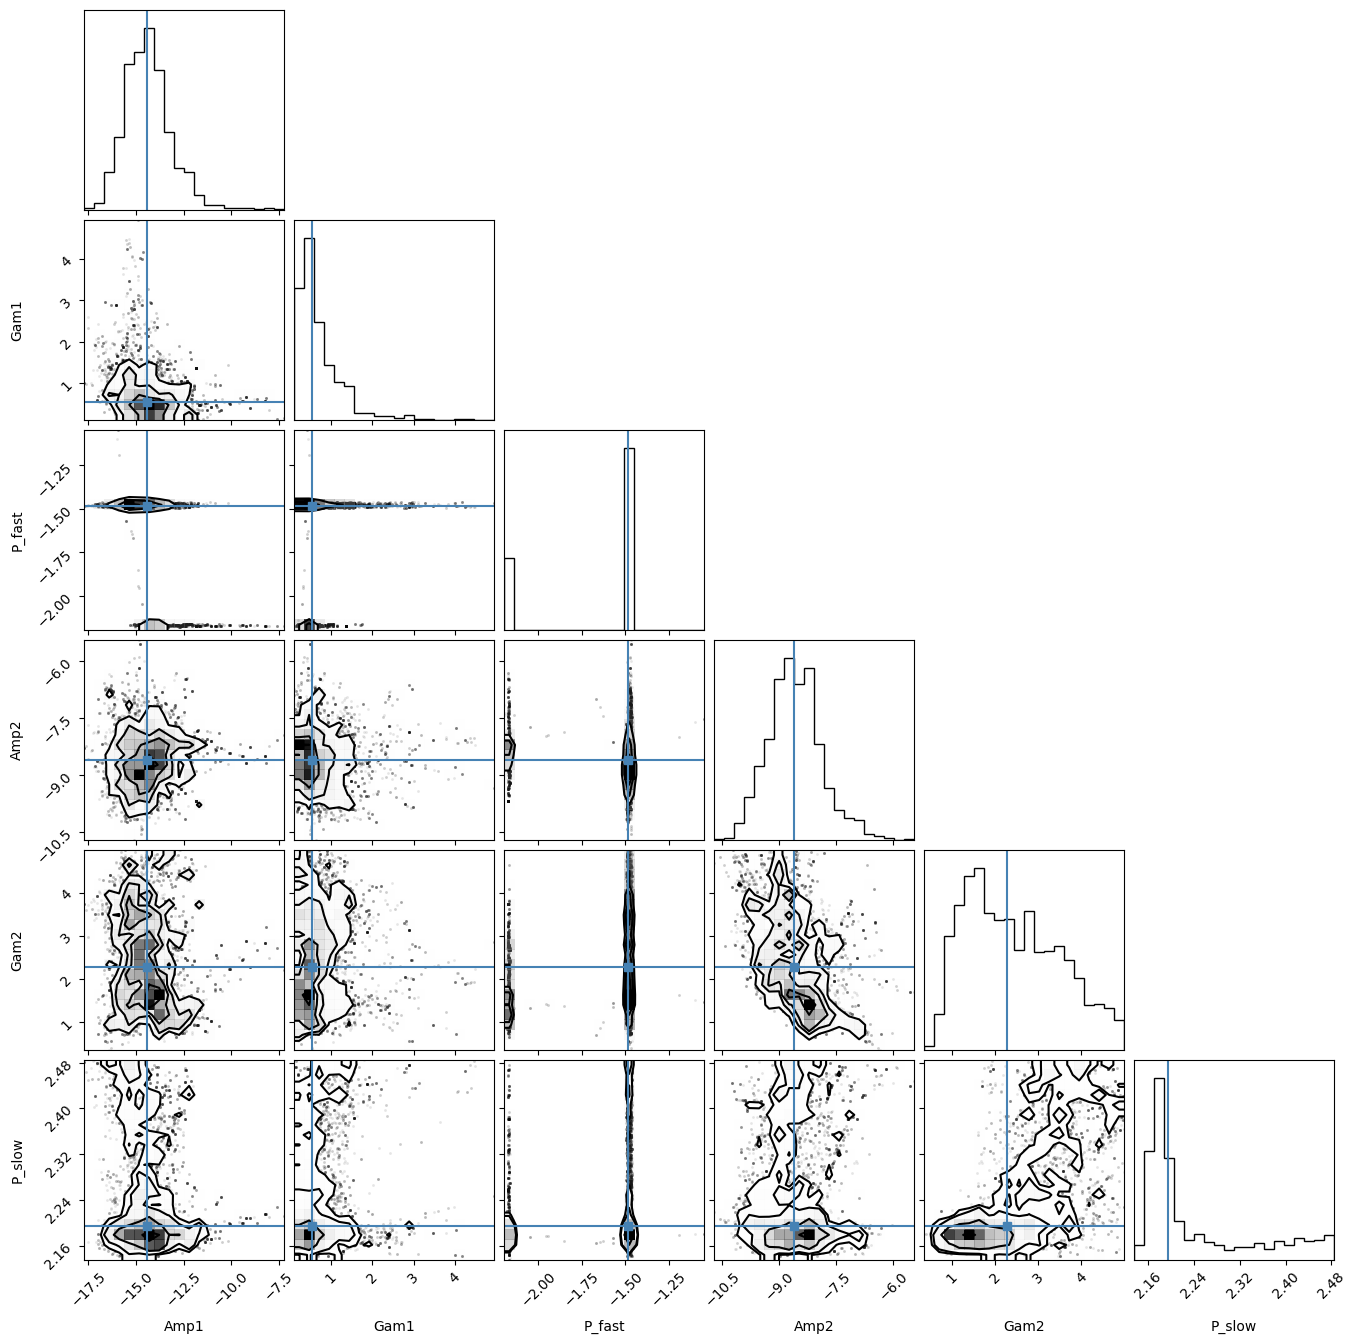

In [ ]:
for v in visits:
    print(f"\n--- Processing Visit: {v.date} ---")
    
    # 1. GP & MCMC Setup
    # Your time is now already sorted and in relative hours from the class
    gp_obj, kf, ks = kernels.get_kernel(v.time, v.white_flux, v.white_error, 0.2, 8.0)
    
    bounds = [
        (None, None), (0.1, 10.0), (np.log(0.1), np.log(0.4)), # Fast
        (None, None), (0.1, 5.0),  (np.log(4.0), np.log(12.0)) # Slow
    ]
    
    samples, mcmc_results, res = modeling.run_mcmc(v.time, v.white_flux, gp_obj, bounds)

    # 2. Extract Best-Fit Parameters and Shaded Uncertainty
    x_pred, mu, gp_std, mu_f, mu_s, residuals, mcmc_mu_samples = modeling.get_best_params(
        gp_obj, v.time, v.white_flux, samples, mcmc_results, kf, ks
    )

    all_waves = v.wave_1d
    entire_range = [(all_waves[0], all_waves[-1])]
    
    binned_results = correction.run_binned_analysis(
    v.time,
    v.flux_2d,
    v.err_2d,
    v.wave_1d,
    gp_obj,
    mcmc_results,
    kf,
    ks,
    wav_ranges=entire_range
)
    pixel_data = correction.get_corrected_pixel_data(
    v.h5_path,
    binned_results
)
    
    # 5. Extract Corrected Pixels and Save
    #pixel_data = correction.get_corrected_pixel_data(v.h5_path, binned_results)
    
    # Plotting & Exports
    plotting.plot_results(v.time, v.white_flux, v.white_error, x_pred, mu, gp_std, mu_f, mu_s, residuals, samples, mcmc_results, mcmc_mu_samples, v.date)
    # plotting.plot_correction_diagnostics(v, binned_results, pixel_data)
    final_output_path = v.h5_path.replace(".h5", "_GP_corrected.h5")
    #file_formatting.save_corr_data(v.h5_path, pixel_data, final_output_path)